# EDA, Data Cleaning & Feature Encoding

This notebook covers the full data preparation pipeline for the Steam Games Hit Prediction project:

1. **Load** the raw dataset from Kaggle (122,611 games, 39 columns)
2. **Audit** each column — null rates, cardinality, outlier counts
3. **Clean** — drop uninformative columns using three criteria
4. **Visualise** distributions of numeric and categorical features
5. **Encode** categorical columns into numeric form for modelling
6. **Statistical analysis** — Spearman correlation and Mann-Whitney U tests
7. **Save** the preprocessed dataset to `csv_files/preprocessed_data.csv`

The output of this notebook feeds directly into `modeling_workflow.ipynb`.

## 1. Loading the Dataset

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub

path = kagglehub.dataset_download("fronkongames/steam-games-dataset")
csv_file = next(Path(path).glob("*.csv"))
df = pd.read_csv(csv_file)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

c:\Users\astep\Documents\Steam-Game-Classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 122,611 rows, 39 columns


## 2. Column Report

We start with a quick `df.describe()` to get basic statistics for numeric columns, then generate a full column report using `column_report()` from `explore.py`.

The column report extends `.describe()` to **all** column types and captures:
- Data type, non-null count, null percentage
- Number of unique values (cardinality)
- IQR-based outlier count and percentage (for numeric columns)
- Sample values

The full report is saved to `column_report.json` for reference.

In [2]:
df.describe()

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


In [3]:
from explore import (
    column_report,
    report_summary,
    report_type_overview,
    save_report,
)

report = column_report(df, n_samples=10)
save_report(report, "column_report.json")
report_summary(report)

Report saved to: column_report.json


,dtype,non_null,null_count,null_pct,n_unique,outlier_count,outlier_pct
column,,,,,,,
AppID,str,122610,1,0.00,121454,NaN,NaN
Name,str,122611,0,0.00,5081,NaN,NaN
Release date,str,122611,0,0.00,14,NaN,NaN
Estimated owners,int64,122611,0,0.00,1110,19676.0,16.05
Peak CCU,int64,122611,0,0.00,15,1272.0,1.04
Required age,float64,122611,0,0.00,941,9297.0,7.58
Price,int64,122611,0,0.00,88,0.0,0.00
DiscountDLC count,int64,122611,0,0.00,117,17771.0,14.49
About the game,str,114162,8449,6.89,113556,NaN,NaN


In [4]:
# Summary by data type: how many columns, which have nulls, which have outliers
report_type_overview(report)

,n_cols,null_cols,avg_null_pct,outlier_cols,columns
dtype,,,,,
bool,3,0,0.00,NaN,"[Windows, Mac, Linux]"
float64,3,2,66.66,1.0,"[Required age, Score rank, Movies]"
int64,14,0,0.00,13.0,"[Estimated owners, Peak CCU, Price, DiscountDL..."
str,19,15,24.95,NaN,"[AppID, Name, Release date, About the game, Su..."


The dataset contains numeric (`int64`, `float64`), boolean, and string columns. Several key observations:
- **Float64**: `Score rank` is 99.97% null and `Movies` is 100% null — both are useless
- **Strings**: 15 out of 19 string columns have at least some missing values; several have very high cardinality
- **Numeric**: 9 out of 14 numeric columns have more than 5% outliers by IQR, indicating heavy right skew

## 3. Visualising Missing Values and Outliers

Before cleaning, we visualise the scale of both problems:

- **Missing values** prevent most ML algorithms from training (they require complete observations)
- **Outliers** can distort distributions and destabilise linear or distance-based models

Outliers are identified using the IQR method: a value is an outlier if it falls below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR`.

  Saved: results/NaN_and_outliners\null_bar.png


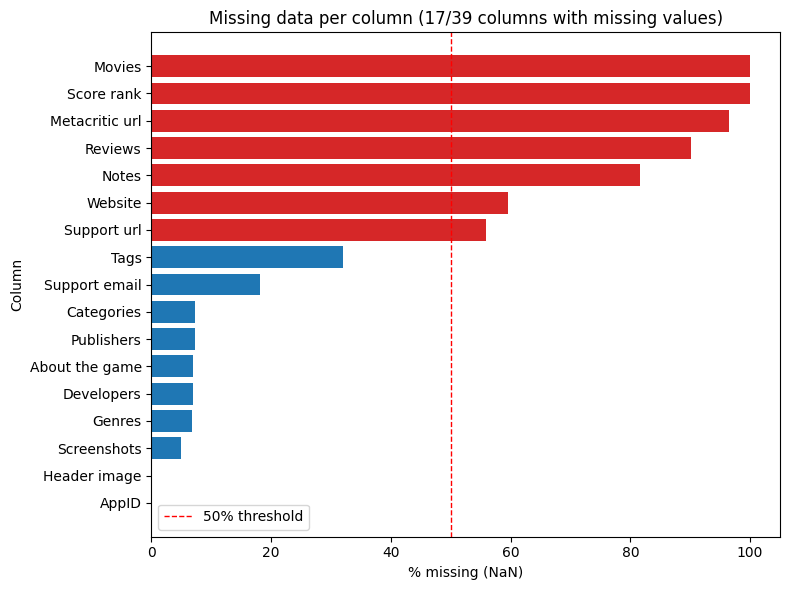

In [5]:
from explore import plot_null_bar, plot_outlier_bar

plot_null_bar(df, save_dir='results/NaN_and_outliners')

**Key findings — missing values:**
12 out of 39 columns have missing values. Critical cases:
- `Movies` (100% NaN), `Score rank` (99.97%), `Metacritic url` (96.5%), `Reviews` (90.2%) — zero information value, will be dropped
- Another 5 columns have 50–60% missing, also making them unusable

  Saved: results/NaN_and_outliners\outlier_bar.png


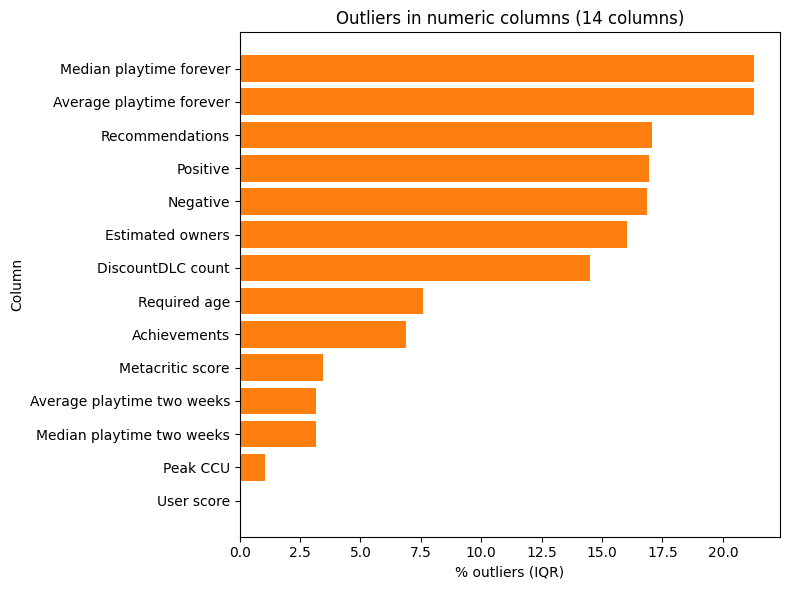

In [6]:
plot_outlier_bar(df, save_dir='results/NaN_and_outliners')

**Key findings — outliers:**
Outliers are widespread: 9 of 14 numeric columns have more than 5% of observations outside the IQR range. The most affected are popularity metrics: `Average/Median playtime forever` (21.3%), `Recommendations` (17.1%), `Positive` and `Negative` (~17%).

This reflects a power-law distribution typical of game popularity — blockbuster titles are rare but have extreme values. We **do not remove these rows** — they represent real popular games and are among the most informative observations in the dataset.

## 4. Data Cleaning

Three criteria are applied to drop uninformative columns:

| Criterion | Threshold | Reasoning |
|---|---|---|
| Too many nulls | `> 50%` missing | Column cannot contribute meaningful information |
| Too low diversity | `> 99%` same value | No discriminative power — effectively a constant |
| Too high cardinality | `> 90%` unique values | Cannot be meaningfully encoded; likely an ID or free-text field |

**Note on `Tags`**: this column contains comma-separated user tags (similar structure to `Categories` and `Genres`) and was considered for inclusion. However, it has 77,000+ unique tag combinations — one-hot encoding it would triple the dataset width, making training prohibitively slow. It was therefore excluded despite potentially carrying useful information.

In [7]:
from clean_data import (
    rename_columns,
    drop_high_null_columns,
    drop_high_cardinality_columns,
    drop_low_diversity_columns,
)

df_dropped_nulls = drop_high_null_columns(df, threshold=50)
df_dropped_lowdiv = drop_low_diversity_columns(df_dropped_nulls, threshold=99)
df_dropped_cardi = drop_high_cardinality_columns(df_dropped_lowdiv, threshold=90)

# Fix misnamed columns (the raw CSV has Name and Release date swapped)
df_renamed = rename_columns(df_dropped_cardi, {
    "Name":         "Release date",
    "Release date": "Owners range",
})

Dropping 8 columns (>50% empty values):
  - Full audio languages: 59.32% empty
  - Reviews: 90.16% empty
  - Website: 59.48% empty
  - Support url: 55.85% empty
  - Metacritic url: 96.53% empty
  - Score rank: 99.97% empty
  - Notes: 81.68% empty
  - Movies: 100.00% empty

Shape before: (122611, 39)
Shape after:  (122611, 31)
Dropping 2 columns (one value dominates >=99%):
  - Windows: 99.96% of values = np.True_
  - User score: 99.97% of values = np.int64(0)

Shape before: (122611, 31)
Shape after:  (122611, 29)
Dropping 5 columns (>90% unique values):
  - AppID: 99.06% unique
  - About the game: 99.47% unique
  - Header image: 99.91% unique
  - Tags: 92.60% unique
  - Screenshots: 99.91% unique

Shape before: (122611, 29)
Shape after:  (122611, 24)
  'Name' -> 'Release date'
  'Release date' -> 'Owners range'


In [8]:
# Verify remaining columns after cleaning
print(f"Remaining columns ({len(df_renamed.columns)}):")
df_renamed.columns.tolist()

Remaining columns (24):


['Release date',
 'Owners range',
 'Estimated owners',
 'Peak CCU',
 'Required age',
 'Price',
 'DiscountDLC count',
 'Supported languages',
 'Support email',
 'Mac',
 'Linux',
 'Metacritic score',
 'Positive',
 'Negative',
 'Achievements',
 'Recommendations',
 'Average playtime forever',
 'Average playtime two weeks',
 'Median playtime forever',
 'Median playtime two weeks',
 'Developers',
 'Publishers',
 'Categories',
 'Genres']

## 5. Distribution Visualisation

We use two complementary approaches to visualise the clean dataset:
- `plot_all_numeric` — standard histograms and boxplots
- `plot_all_categorical` — pie and bar charts for string columns

Standard histograms reveal a problem: nearly all numeric columns are **dominated by zeros** (most Steam games have no reviews, no playtime, no owners). This makes conventional plots uninformative.

  Saved: results/visualization_num\numeric_Estimated_owners.png


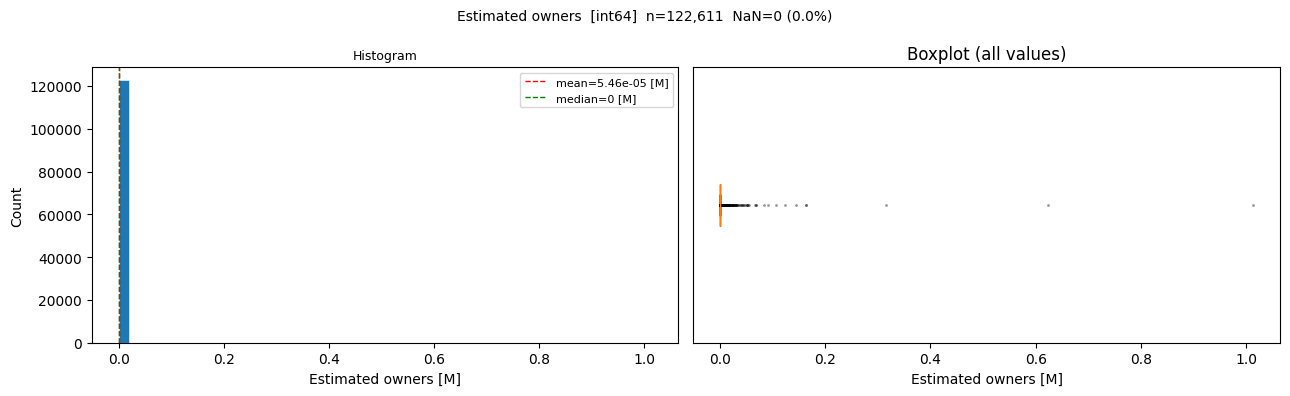

  Saved: results/visualization_num\numeric_Peak_CCU.png


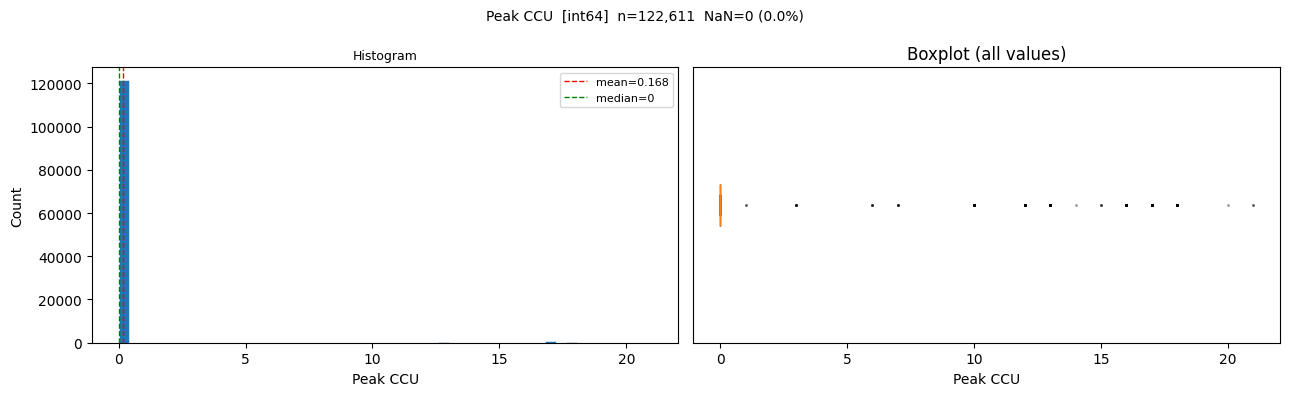

  Saved: results/visualization_num\numeric_Required_age.png


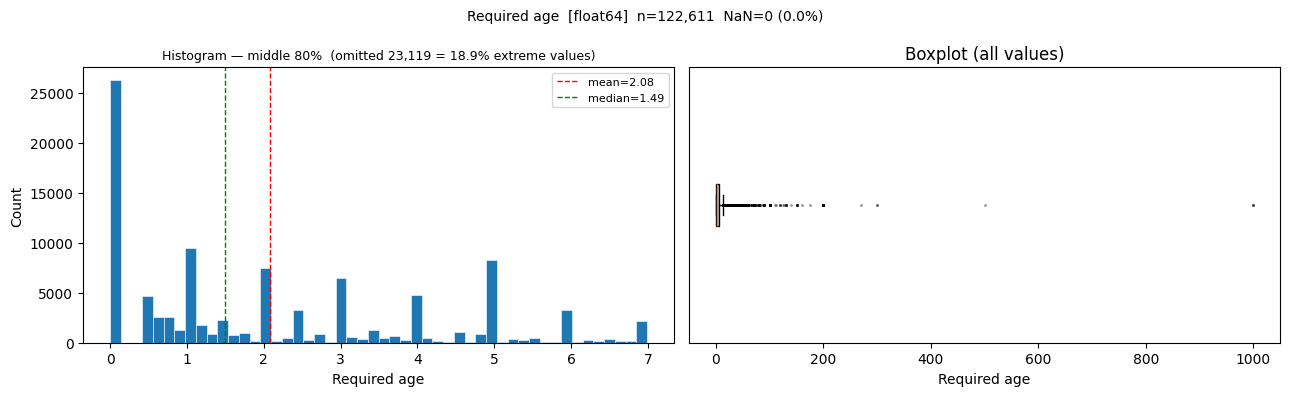

  Saved: results/visualization_num\numeric_Price.png


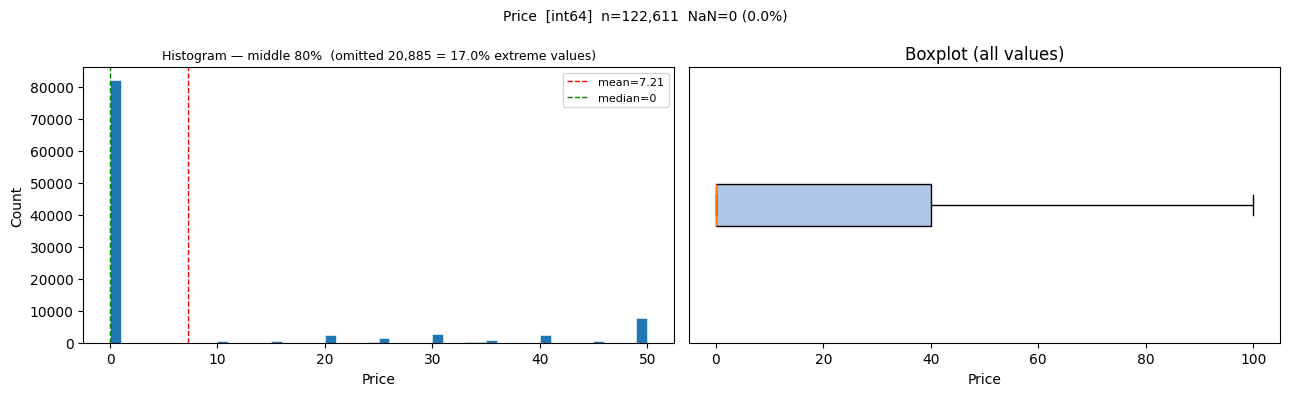

  Saved: results/visualization_num\numeric_DiscountDLC_count.png


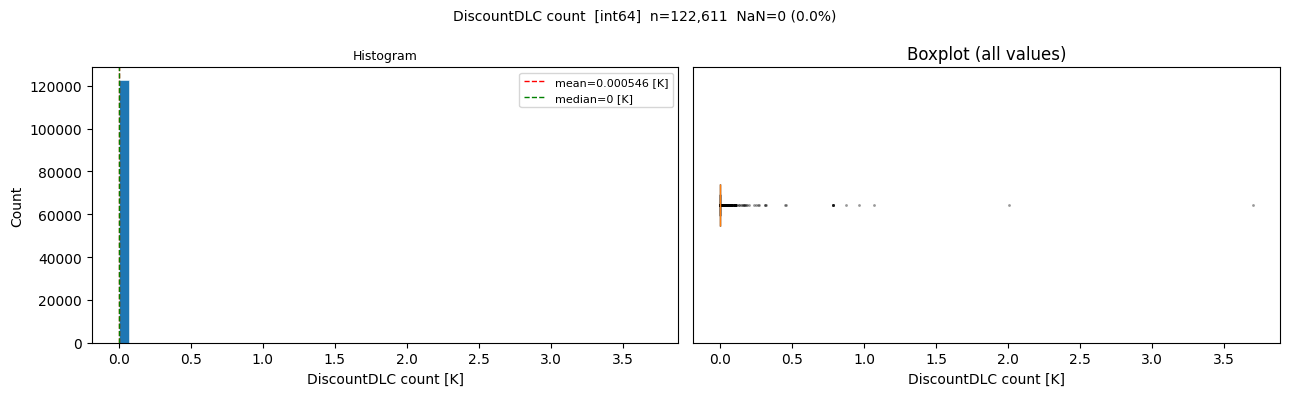

  Saved: results/visualization_num\numeric_Metacritic_score.png


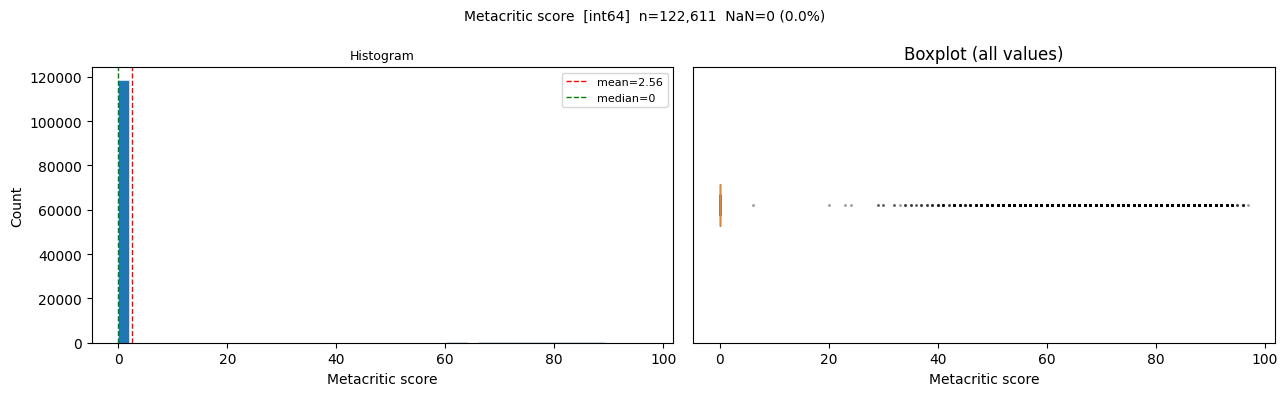

  Saved: results/visualization_num\numeric_Positive.png


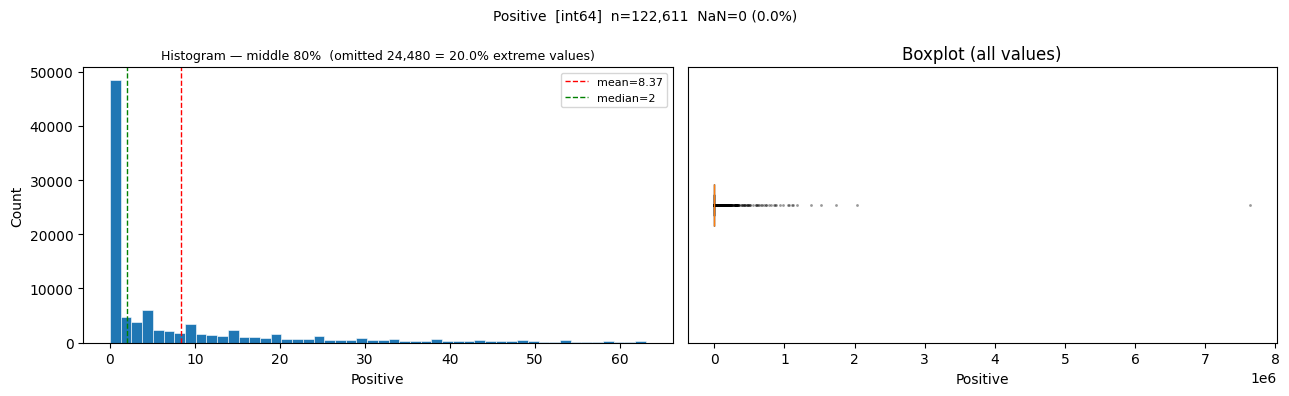

  Saved: results/visualization_num\numeric_Negative.png


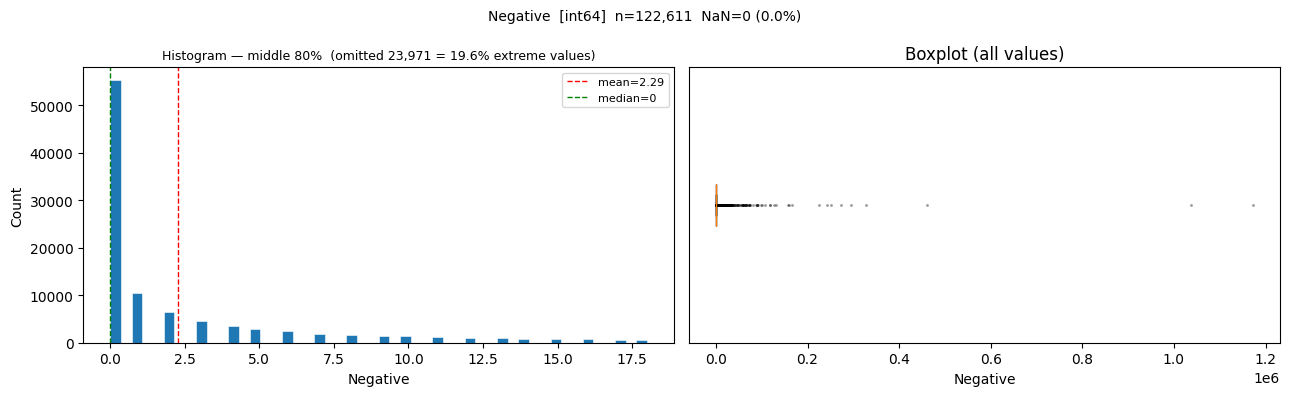

  Saved: results/visualization_num\numeric_Achievements.png


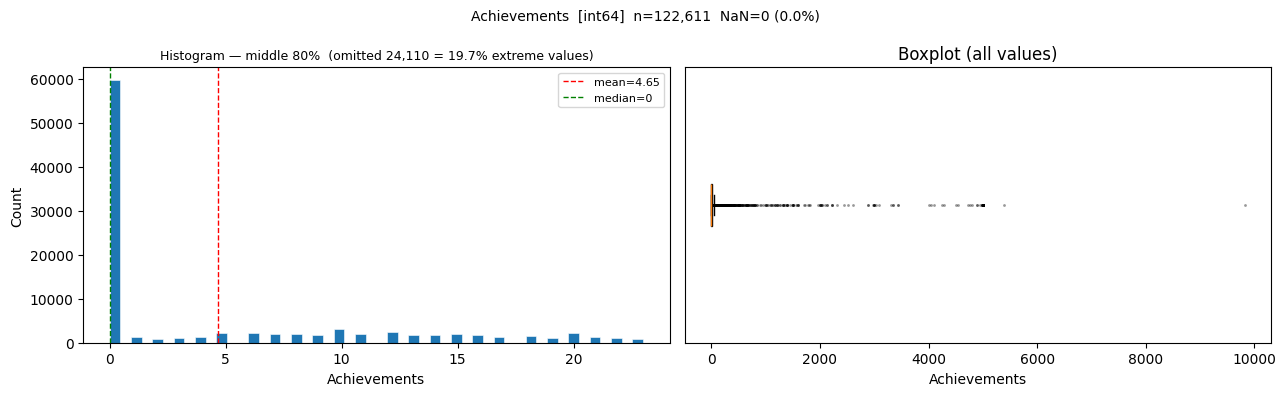

  Saved: results/visualization_num\numeric_Recommendations.png


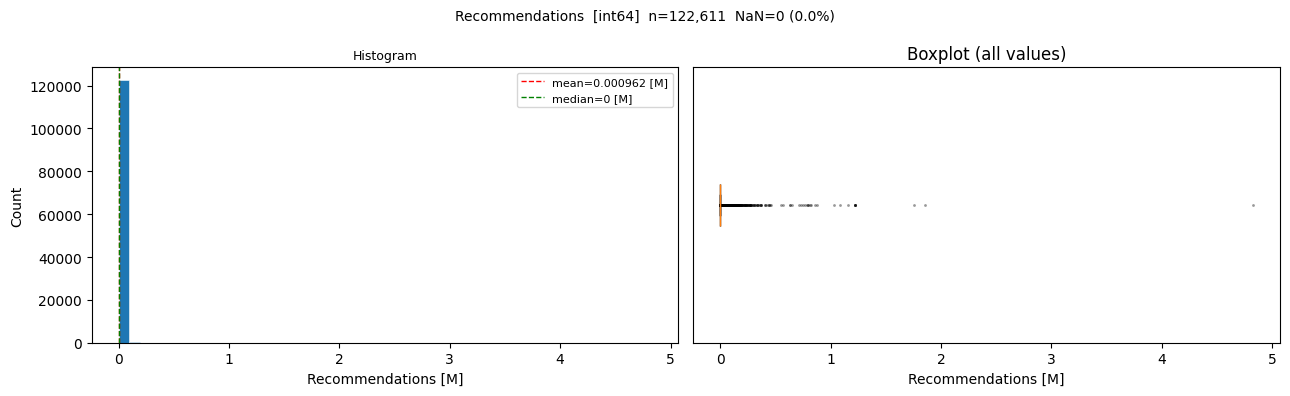

  Saved: results/visualization_num\numeric_Average_playtime_forever.png


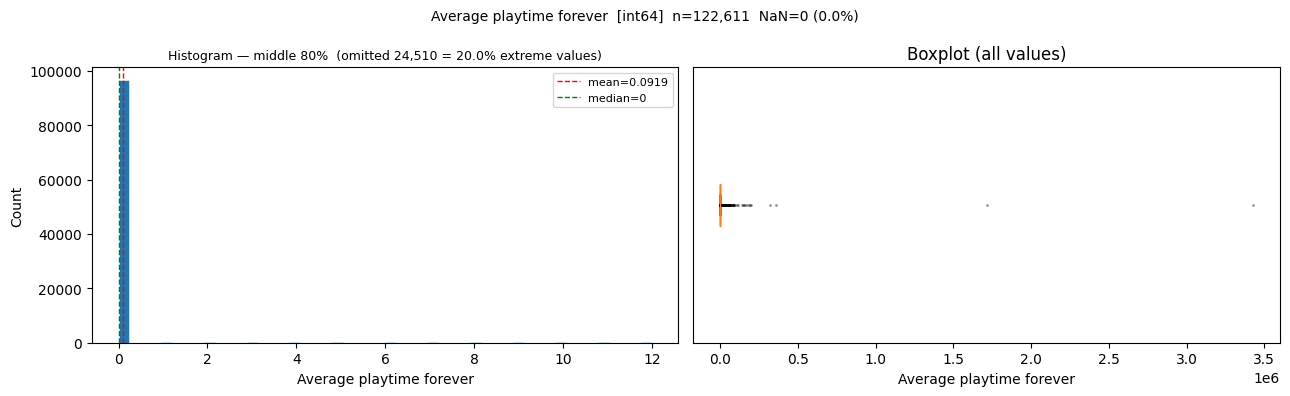

  Saved: results/visualization_num\numeric_Average_playtime_two_weeks.png


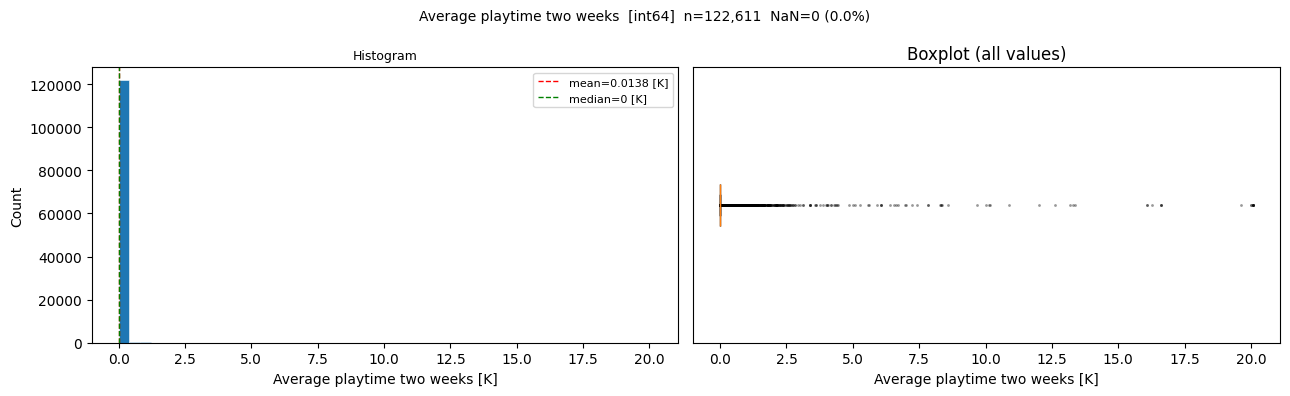

  Saved: results/visualization_num\numeric_Median_playtime_forever.png


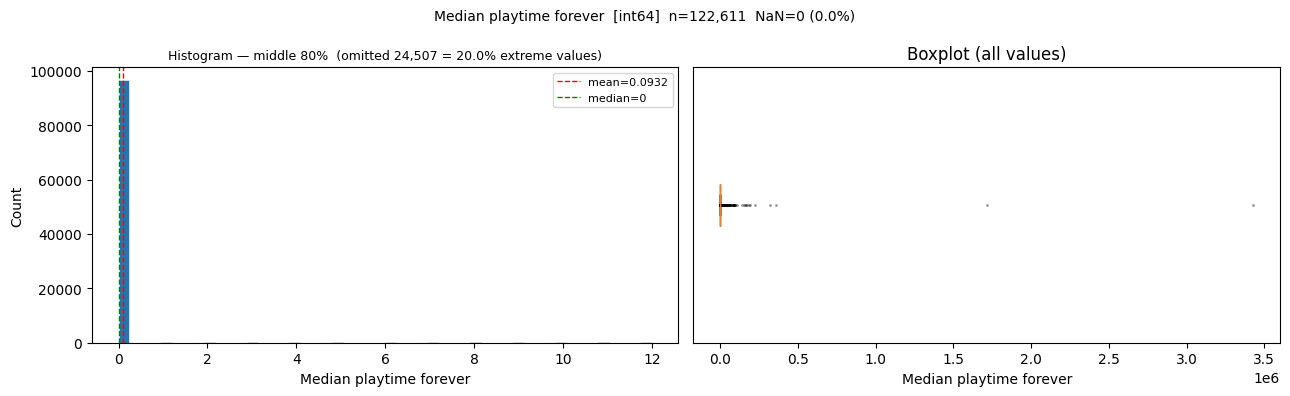

  Saved: results/visualization_num\numeric_Median_playtime_two_weeks.png


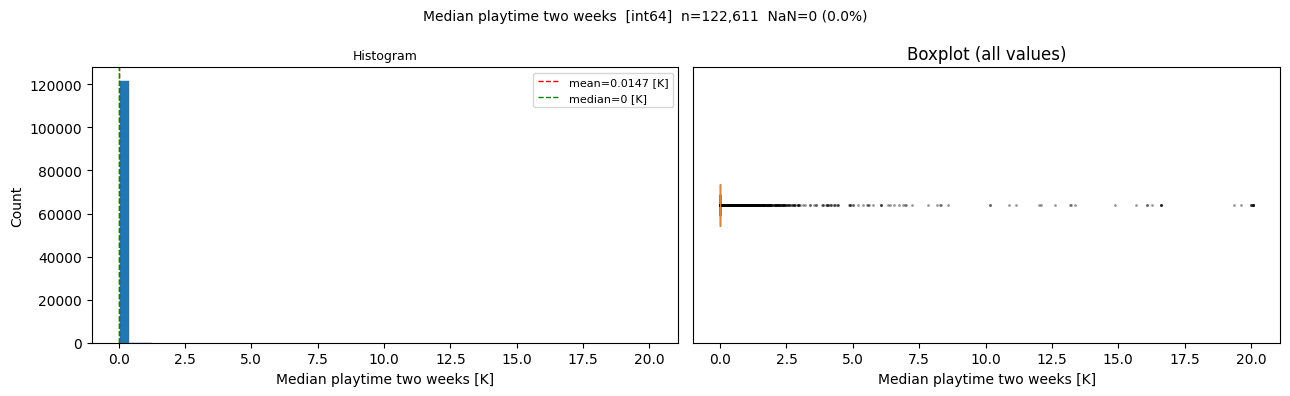

                            min         max       mean  median         std  \
column                                                                       
Estimated owners            0.0  1013936.00    54.5933    0.00   3729.4516   
Peak CCU                    0.0       21.00     0.1676    0.00      1.6536   
Required age                0.0      999.98     4.7651    2.24     12.5310   
Price                       0.0      100.00    18.3537    0.00     28.8590   
DiscountDLC count           0.0     3703.00     0.5459    0.00     14.5160   
Metacritic score            0.0       97.00     2.5649    0.00     13.6606   
Positive                    0.0  7642084.00  1044.9861    5.00  28091.7299   
Negative                    0.0  1173003.00   169.1974    1.00   5374.6449   
Achievements                0.0     9821.00    18.0870    2.00    141.4939   
Recommendations             0.0  4830455.00   961.8250    0.00  21878.8040   
Average playtime forever    0.0  3429544.00   208.0232    0.00  

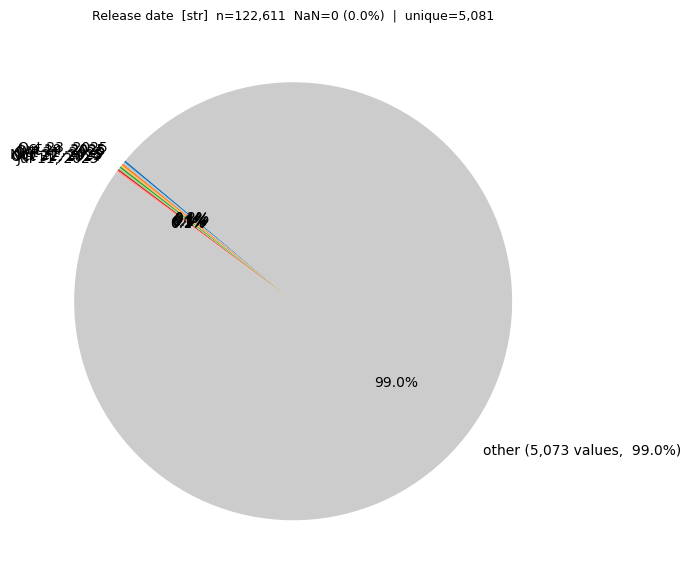

  Saved: results/visualization_cat\categorical_Owners_range.png


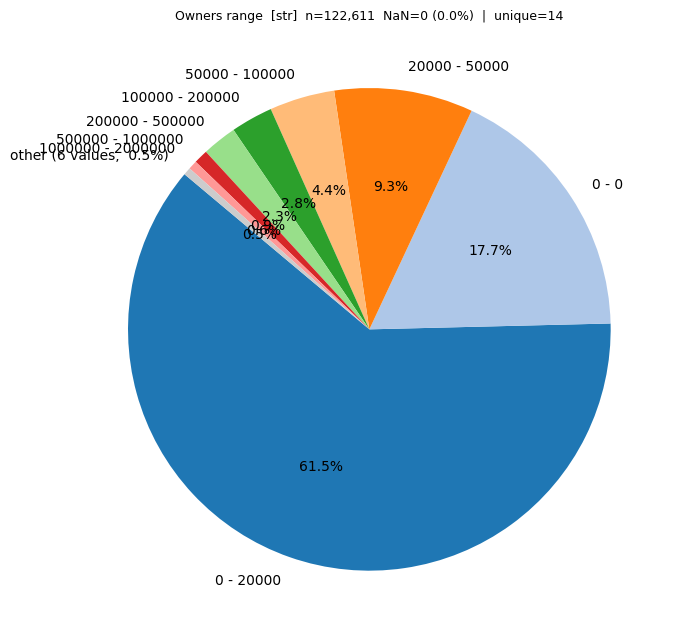

  Saved: results/visualization_cat\categorical_Supported_languages.png


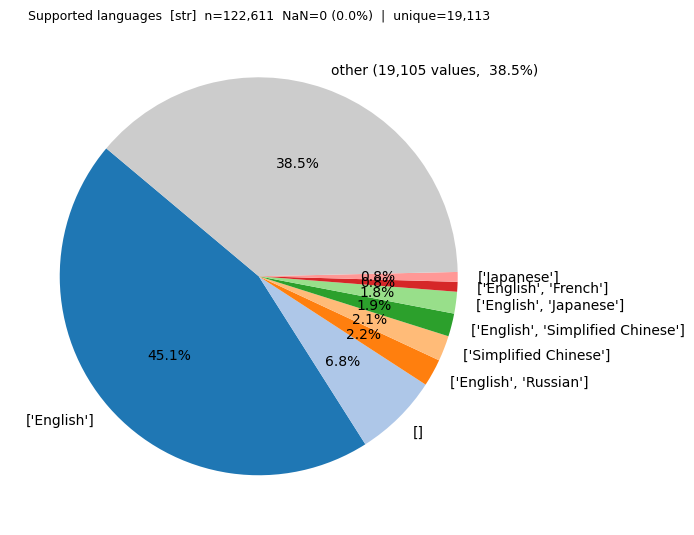

  Saved: results/visualization_cat\categorical_Support_email.png


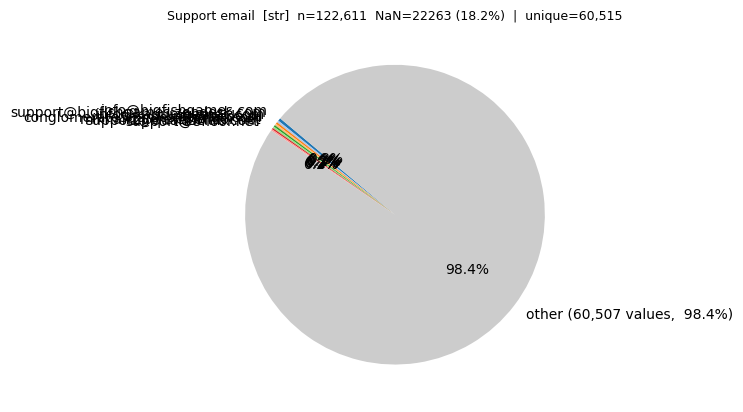

  Saved: results/visualization_cat\categorical_Mac.png


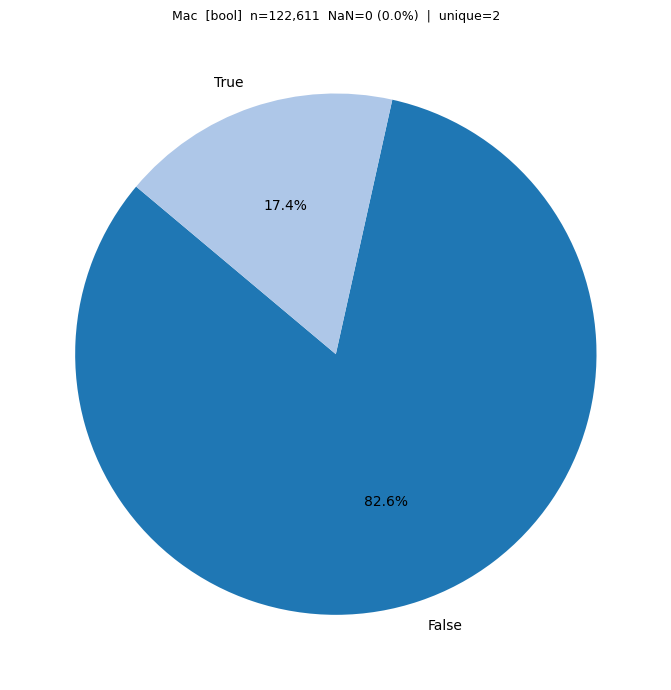

  Saved: results/visualization_cat\categorical_Linux.png


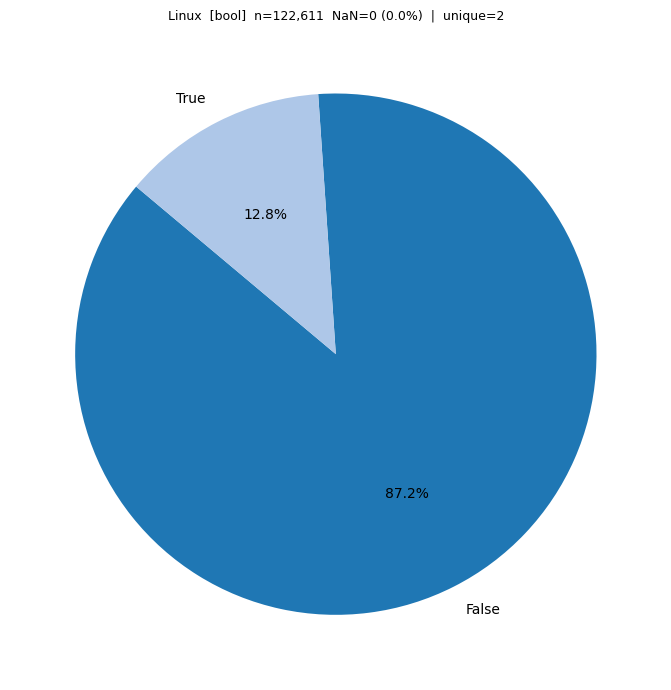

  Saved: results/visualization_cat\categorical_Developers.png


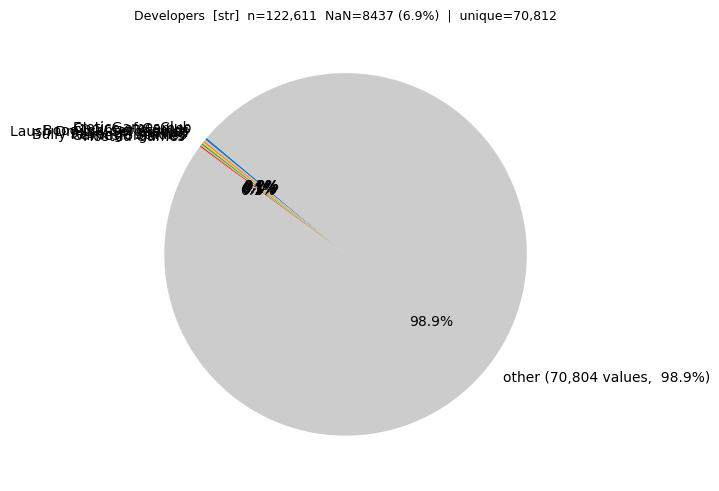

  Saved: results/visualization_cat\categorical_Publishers.png


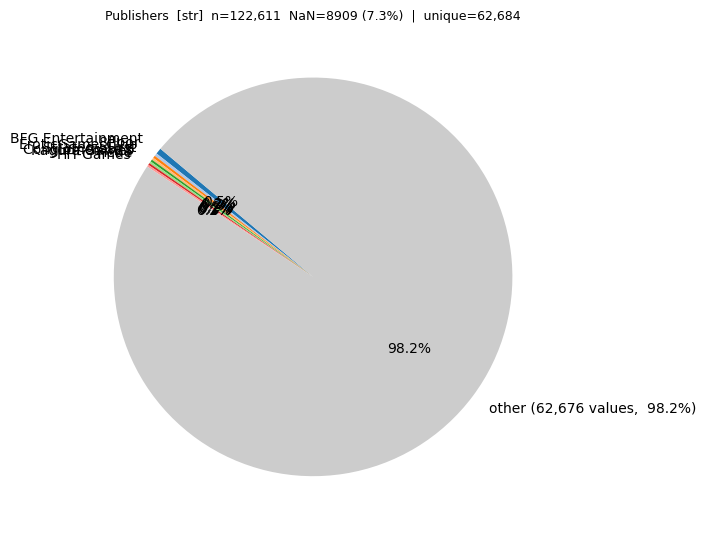

  Saved: results/visualization_cat\categorical_Categories.png


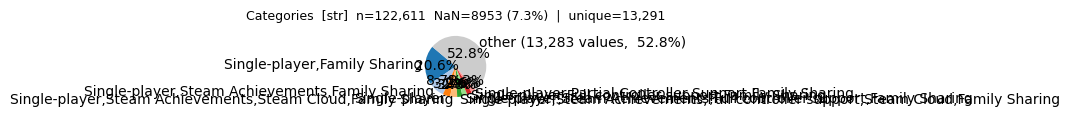

  Saved: results/visualization_cat\categorical_Genres.png


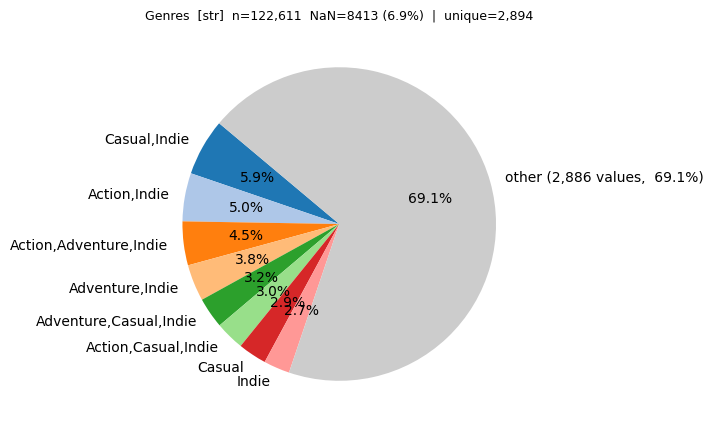

In [9]:
from explore import plot_all_numeric, plot_all_categorical, plot_log_distribution

stats = plot_all_numeric(df_renamed, save_dir='results/visualization_num')
print(stats)
plot_all_categorical(df_renamed, chart="pie", top_n=8, save_dir='results/visualization_cat')

### Log-transformed distributions

For columns with heavy right skew, we apply two alternative visualisation methods with a `log(1+x)` transform to suppress the zero mass and better reveal the distribution shape:

- **ECDF** (*Empirical Cumulative Distribution Function*) — shows the cumulative distribution without arbitrary binning. Any percentile can be read directly from the plot, and data density is visible across the full range.
- **Boxenplot** (*letter-value plot*) — an extended boxplot that displays multiple quantile levels rather than just Q1/Q3. Particularly readable for long-tailed distributions — each "letter" band shows how many observations fall at that quantile level.

  Saved: results/visualization_num_log\log_dist_Estimated_owners.png


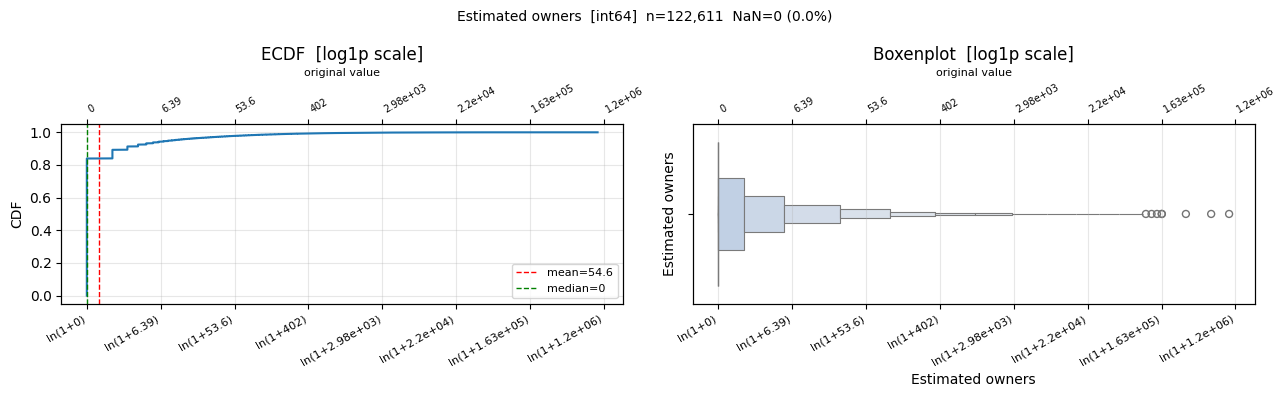

  Saved: results/visualization_num_log\log_dist_Peak_CCU.png


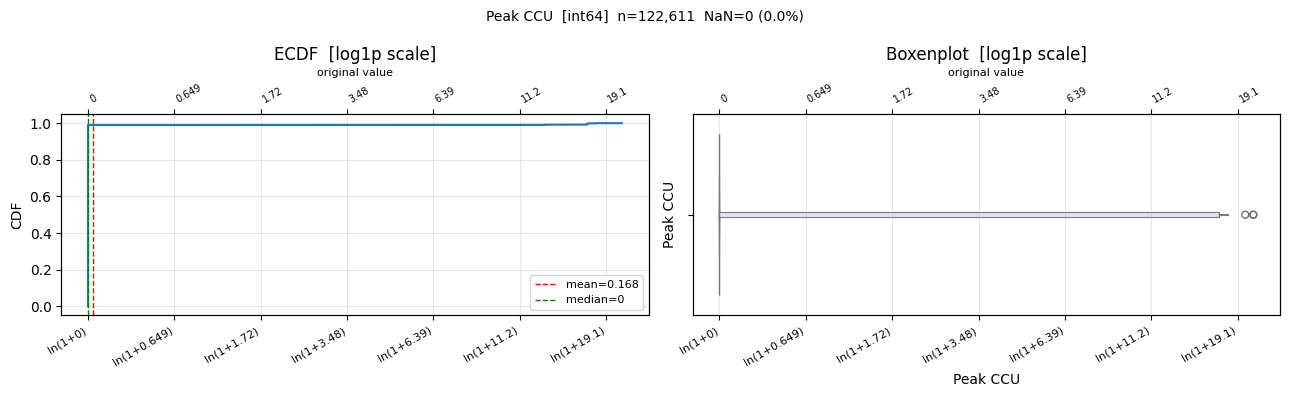

  Saved: results/visualization_num_log\log_dist_Required_age.png


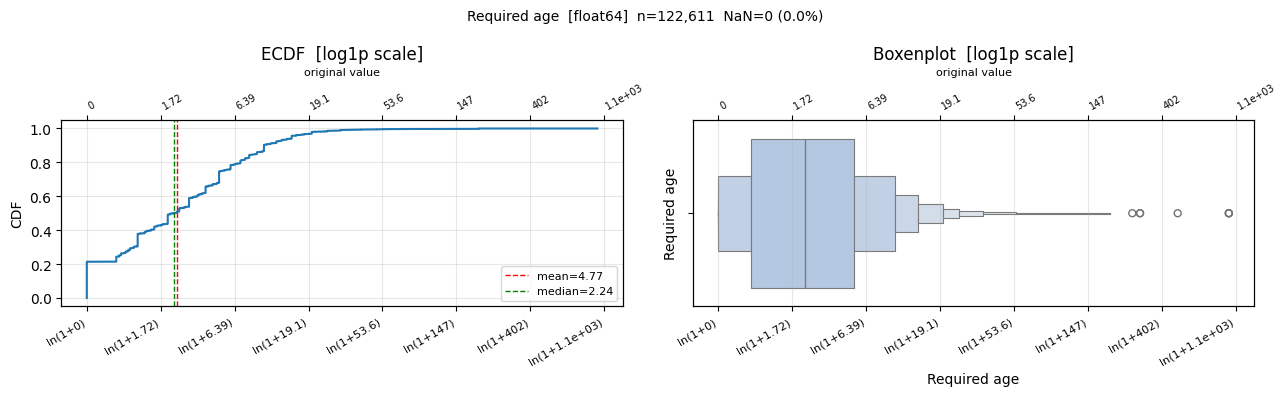

  Saved: results/visualization_num_log\log_dist_Price.png


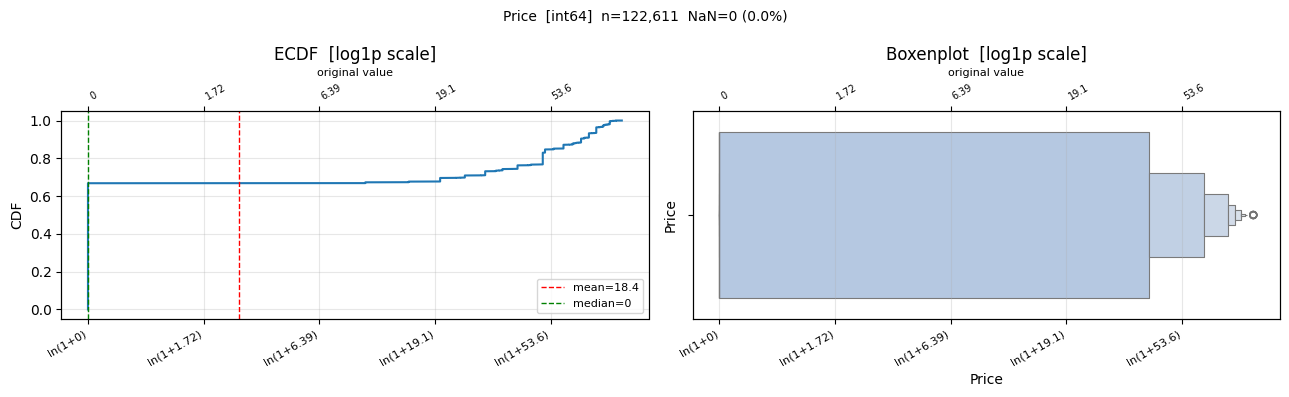

  Saved: results/visualization_num_log\log_dist_DiscountDLC_count.png


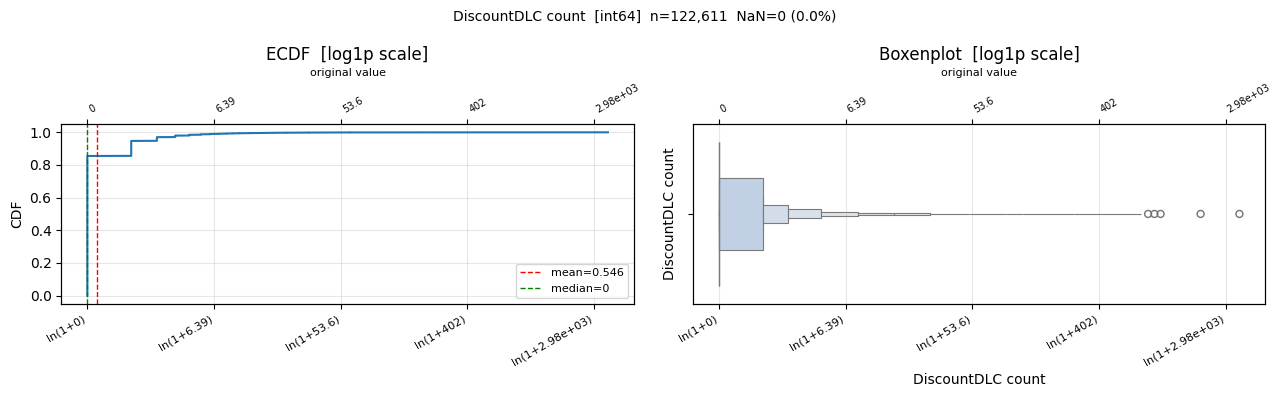

  Saved: results/visualization_num_log\log_dist_Metacritic_score.png


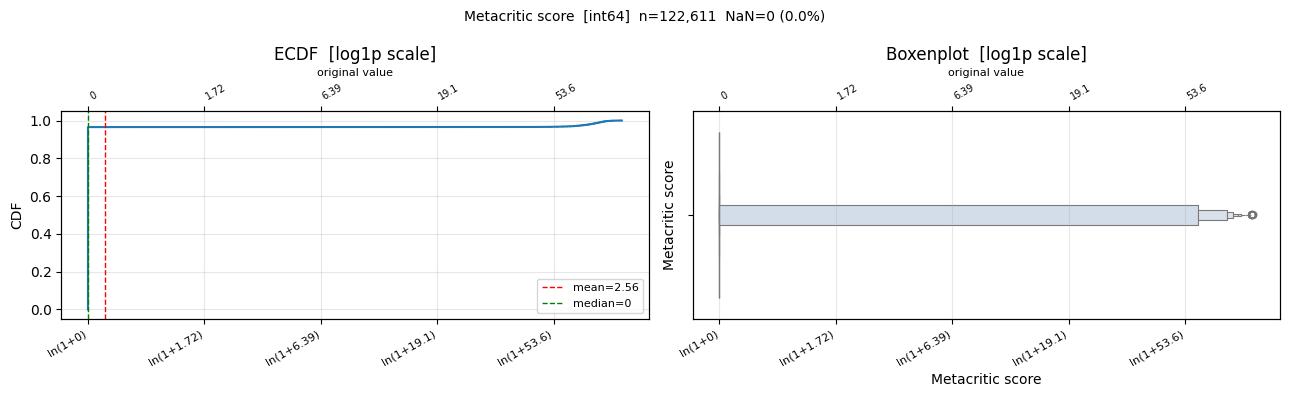

  Saved: results/visualization_num_log\log_dist_Positive.png


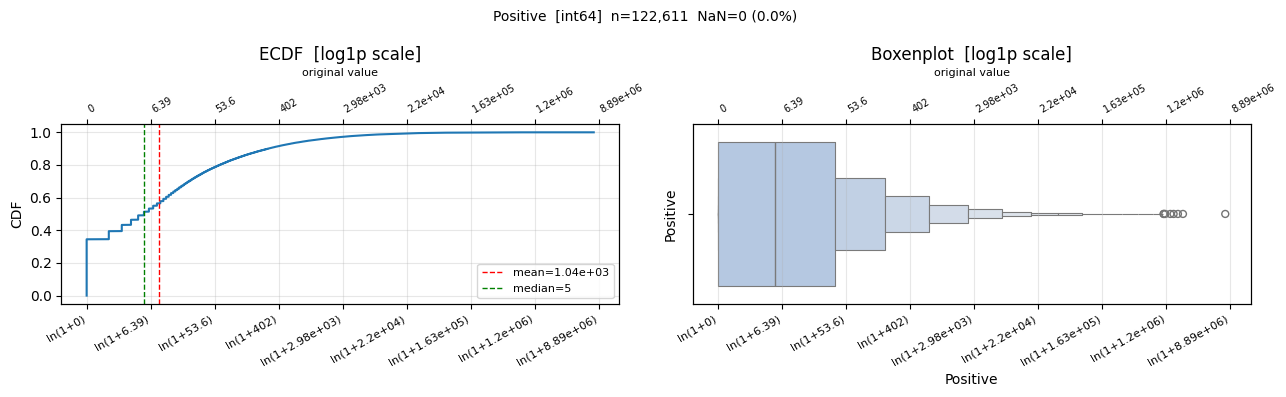

  Saved: results/visualization_num_log\log_dist_Negative.png


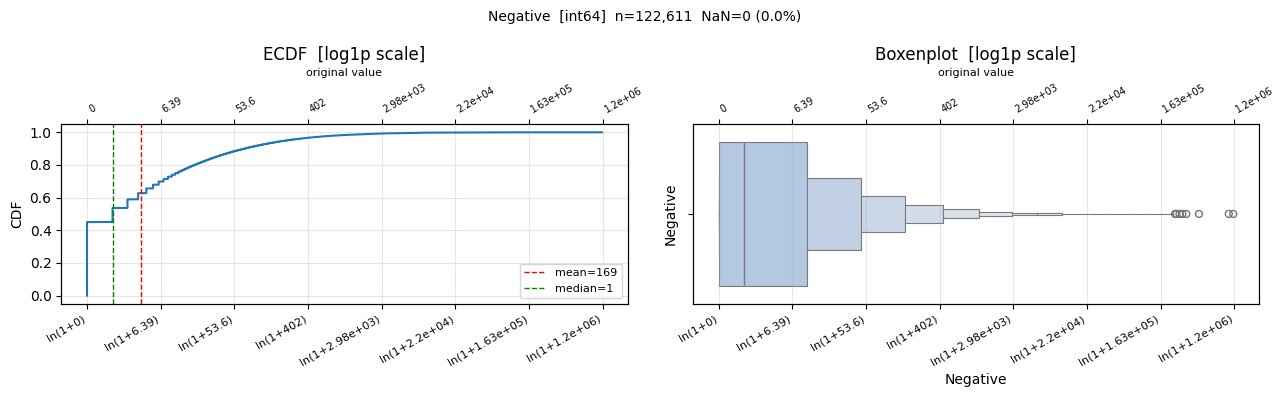

  Saved: results/visualization_num_log\log_dist_Achievements.png


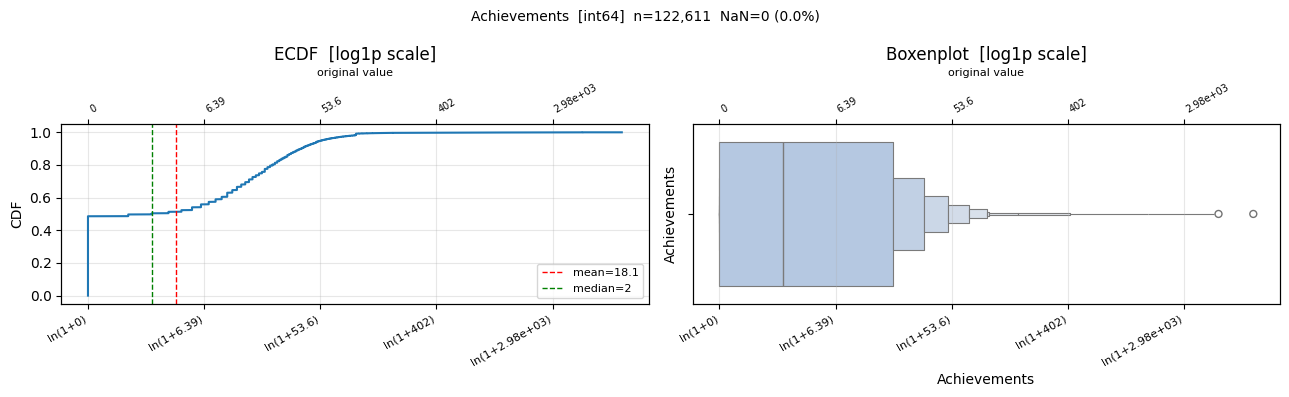

  Saved: results/visualization_num_log\log_dist_Recommendations.png


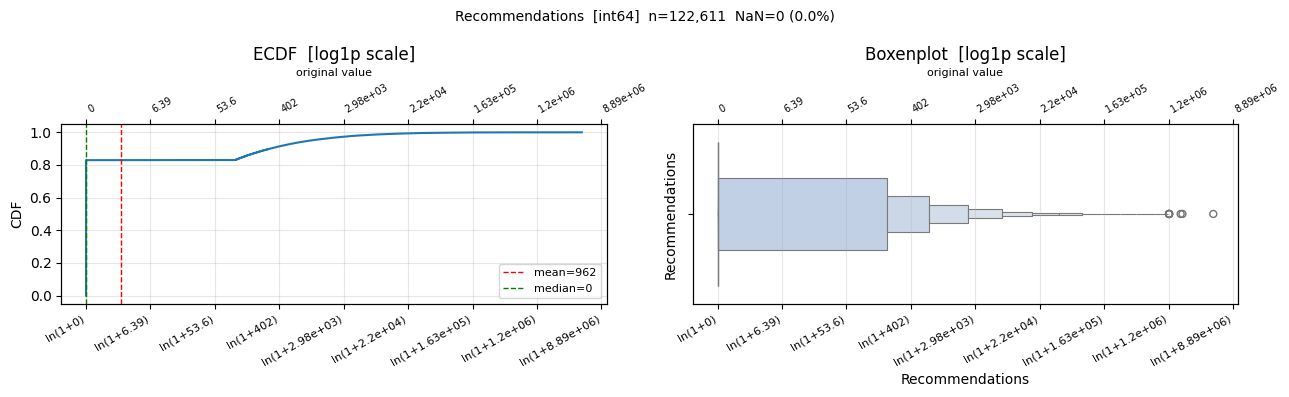

  Saved: results/visualization_num_log\log_dist_Average_playtime_forever.png


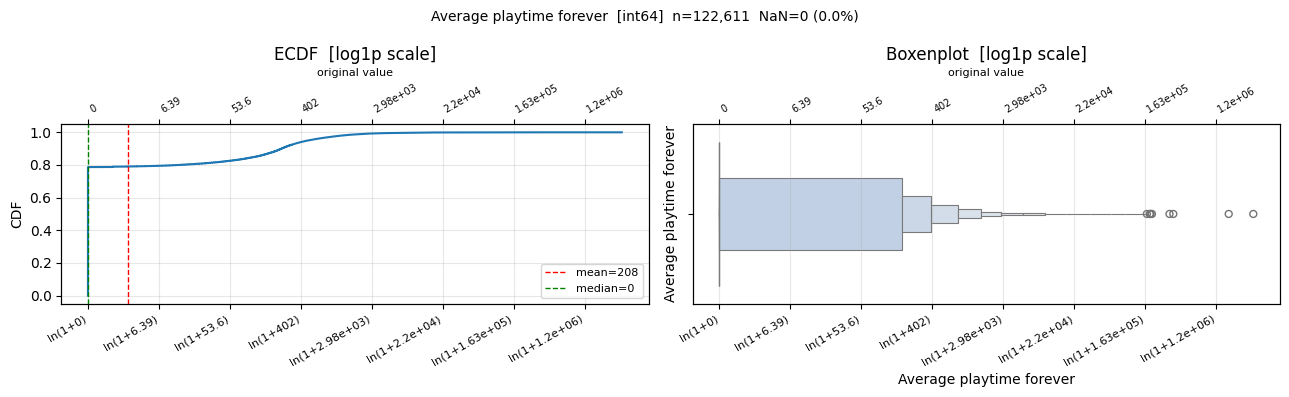

  Saved: results/visualization_num_log\log_dist_Average_playtime_two_weeks.png


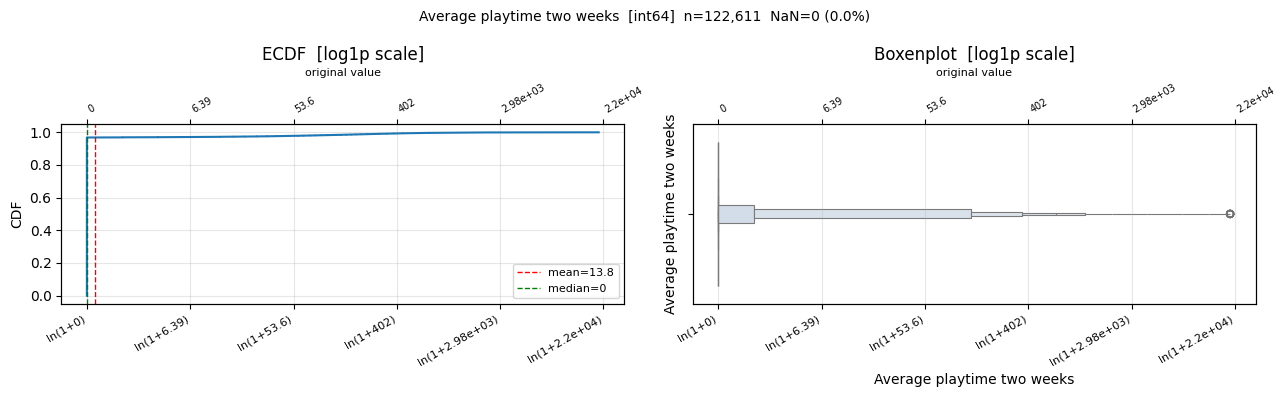

  Saved: results/visualization_num_log\log_dist_Median_playtime_forever.png


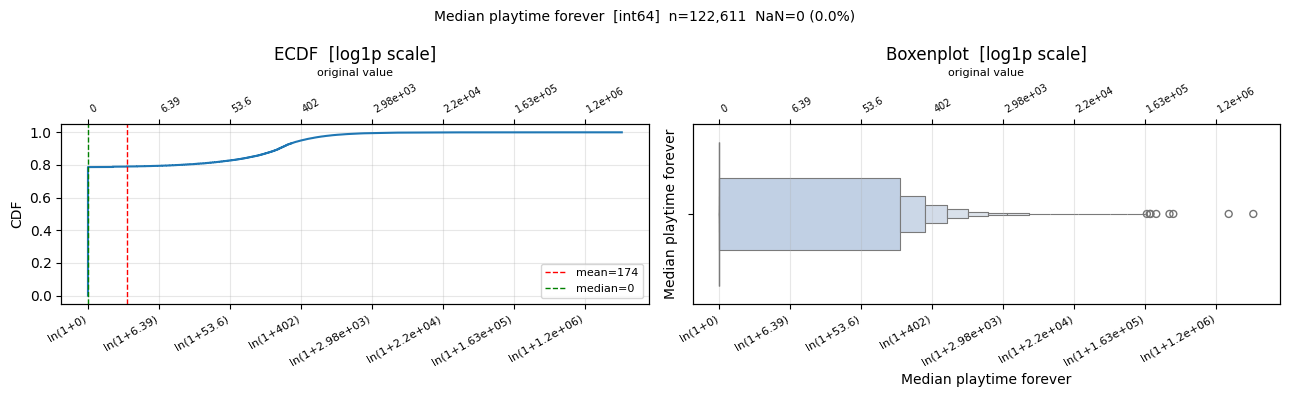

  Saved: results/visualization_num_log\log_dist_Median_playtime_two_weeks.png


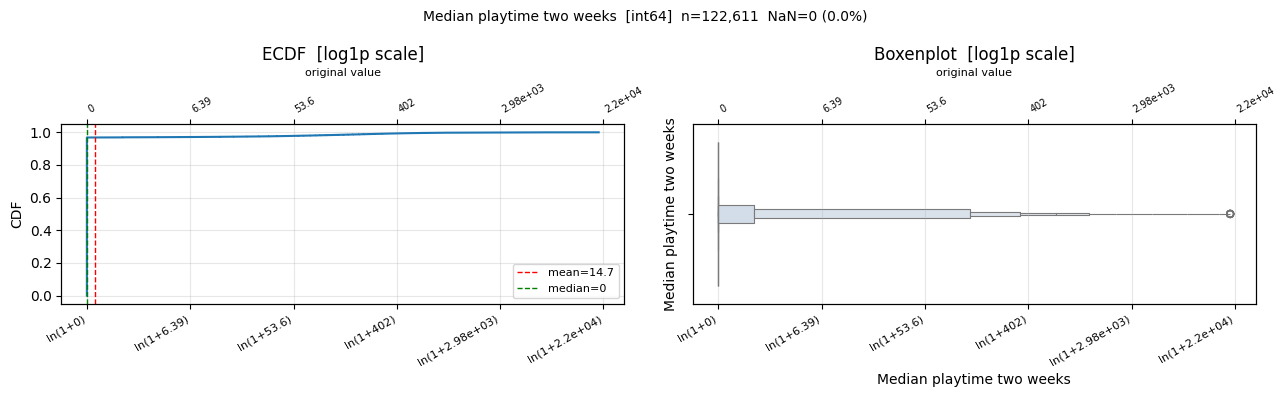

In [10]:
stats = plot_log_distribution(df_renamed, save_dir='results/visualization_num_log')

## 6. Categorical Feature Encoding

All categorical columns must be converted to numeric form before model training. The encoding strategy for each column type:

| Column(s) | Encoding | Result |
|---|---|---|
| `Release date` | Days since earliest date in dataset | Single numeric column — preserves chronological order |
| `Owners range` | Midpoint of range string (e.g. `"1000–2000"` → `1500`) | Single numeric column |
| `Mac`, `Linux` | Boolean → 0 / 1 | No change in dimensionality |
| `Supported languages` | One-hot (top 10 languages + `other`) | 11 binary columns |
| `Categories`, `Genres` | One-hot per unique tag | 58 + 33 binary columns |
| `Developers`, `Publishers` | Frequency encoding + top-50 binary flag | 3 columns each (frequency value, is_top flag, missing indicator) |

In [11]:
from transform_categorical import (
    transform_freq_top,
    transform_release_date,
    transform_owners_range,
    transform_bool_columns,
    transform_supported_languages,
    transform_comma_columns,

)

df_transform_date = transform_release_date(df_renamed)
df_transform_owners = transform_owners_range(df_transform_date)
df_transform_bool = transform_bool_columns(df_transform_owners)
df_transform_supported = transform_supported_languages(df_transform_bool)
df_transform_type = transform_comma_columns(df_transform_supported, cols=["Categories", "Genres", "Tags"])
df_transform_company = transform_freq_top(df_transform_type, cols=["Developers", "Publishers"], top_n=50)
df_final = df_transform_company.copy()

  Transforming 'Categories' -> prefix 'categories'
  Transforming 'Genres' -> prefix 'genres'
  Column 'Tags' does not exist — skipping.
  'Developers' -> developers_frequency, developers_is_top, dont_have_developers  (top_n=50, unique values=75469)
  'Publishers' -> publishers_frequency, publishers_is_top, dont_have_publishers  (top_n=50, unique values=62672)


In [12]:
print(f"Dataset shape after encoding: {df_final.shape}")

Dataset shape after encoding: (122611, 130)


  Saved: results/post_transform\post_languages.png


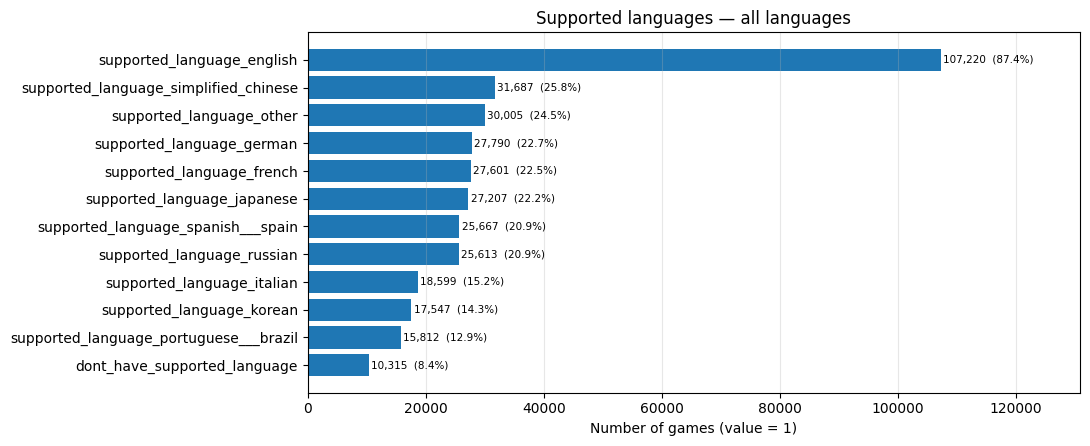

  Saved: results/post_transform\post_categories.png


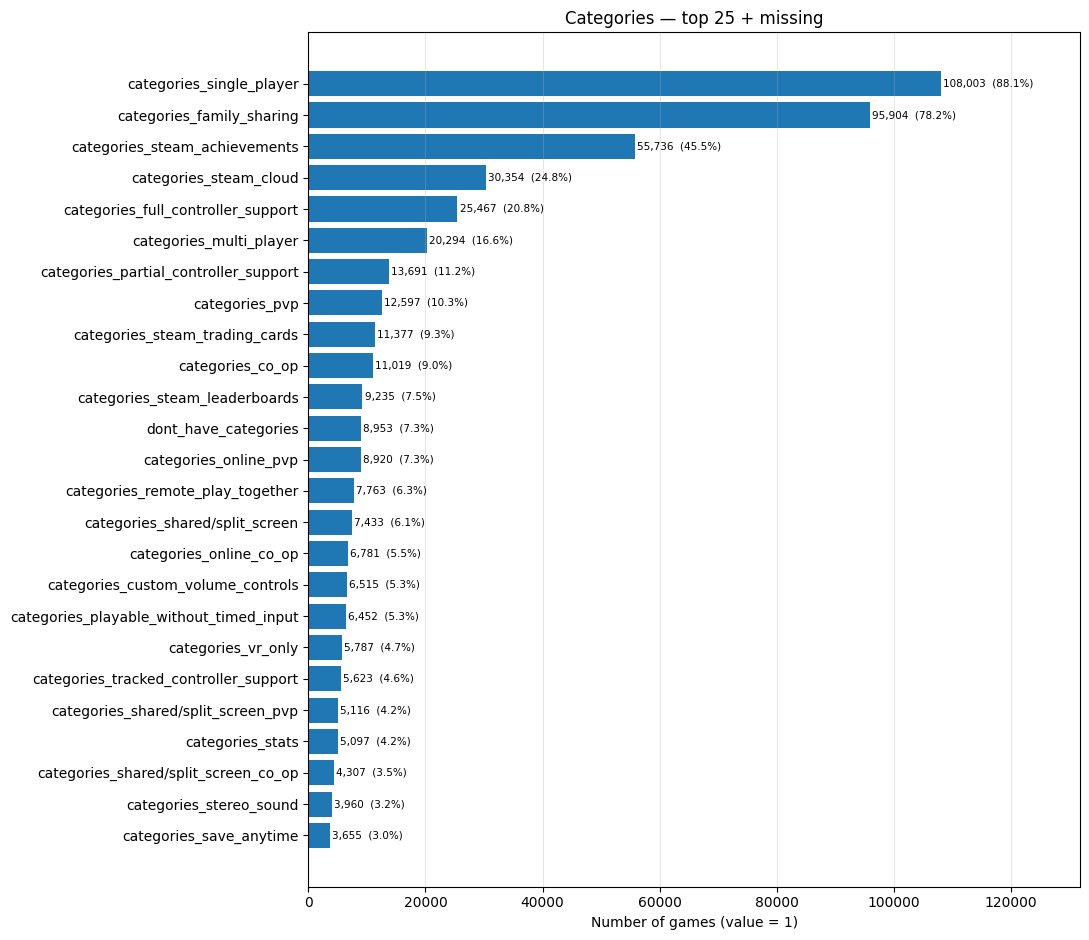

  Saved: results/post_transform\post_genres.png


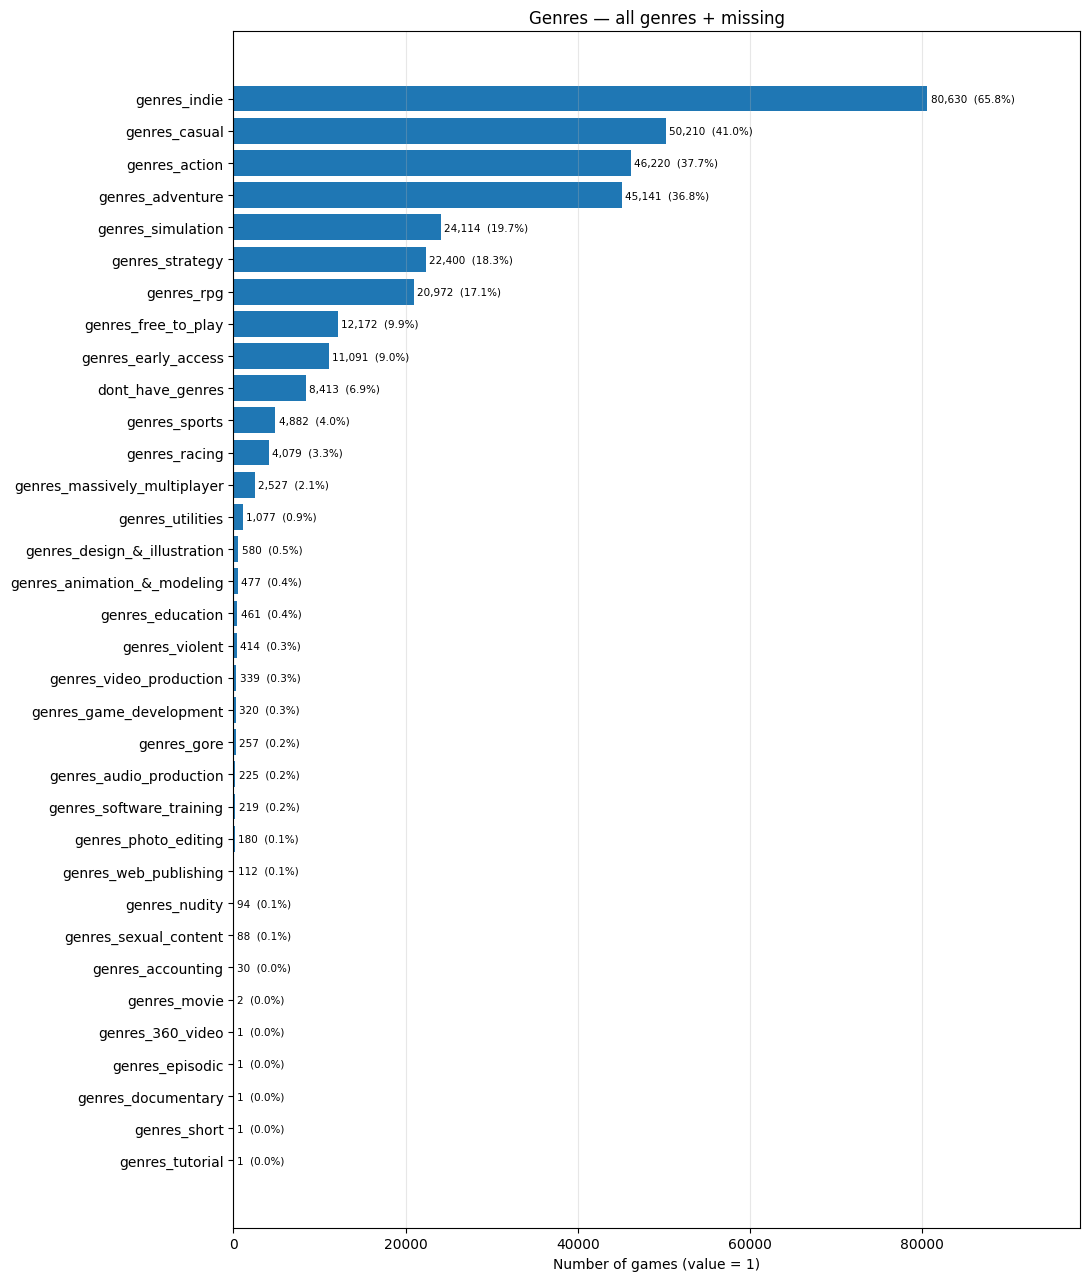

  Saved: results/post_transform\post_developers_summary.png


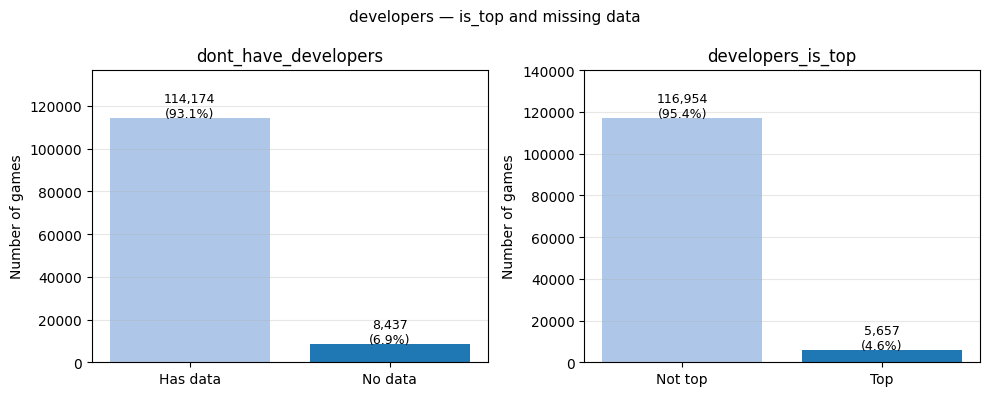

  Saved: results/post_transform\post_publishers_summary.png


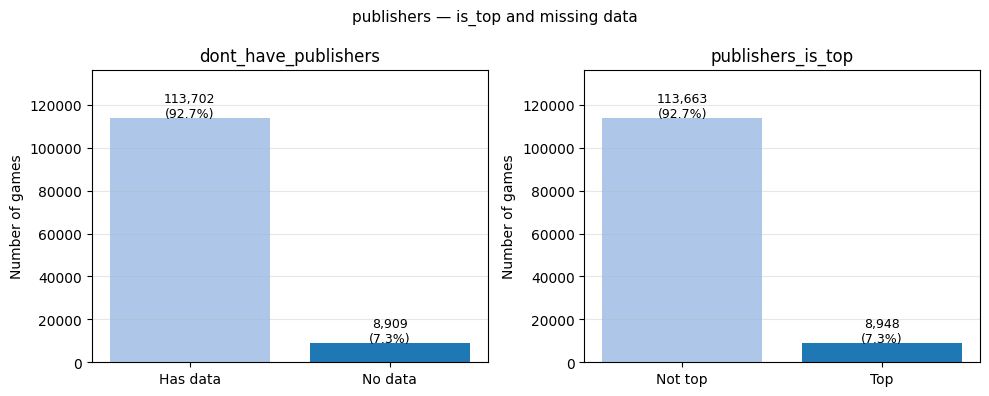

  Saved: results/post_transform\post_developers_frequency.png


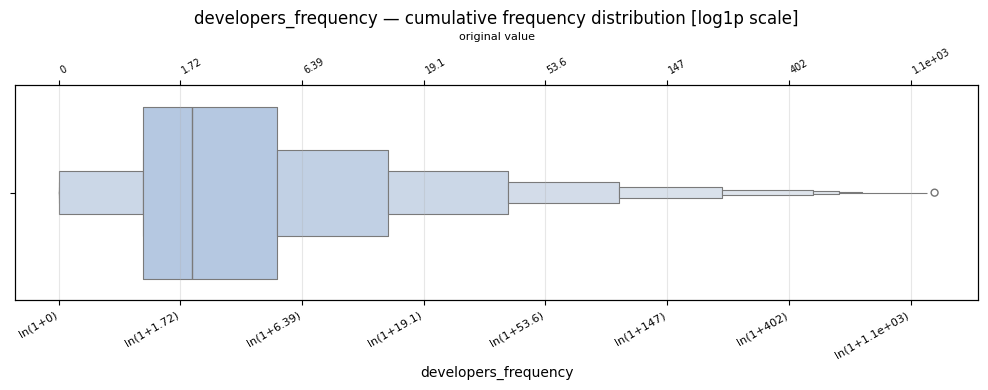

  Saved: results/post_transform\post_publishers_frequency.png


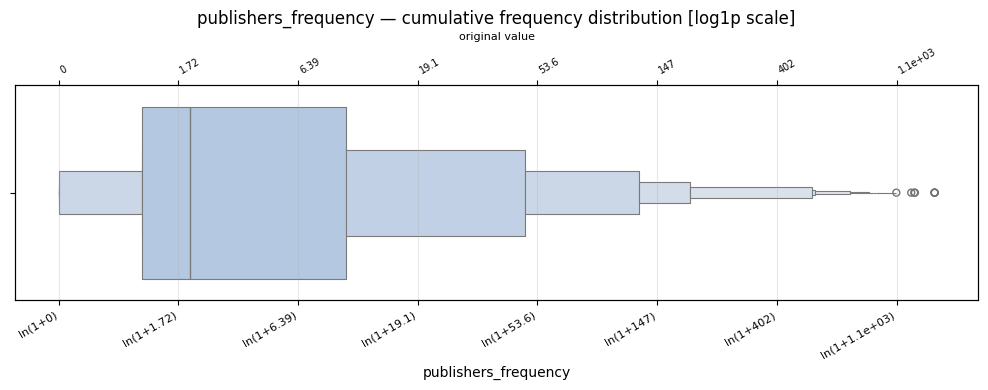

In [13]:
# Visualise the one-hot encoded columns to check for reasonable value distributions
from explore import plot_post_transform

plot_post_transform(df_final, top_n=25, save_dir='results/post_transform')

### Drop `Support email`

The `Support email` column contains thousands of unique email addresses. It carries no signal about game popularity and could introduce noise. It is also a privacy concern — email addresses should not be retained in training data.

In [14]:
if "Support email" in df_final.columns:
    df_final.drop(columns=["Support email"], inplace=True)

### Cast all columns to float32 and save

All remaining columns should now be numeric. We verify this with `column_types_summary`, cast to `float32` for memory efficiency, and save the result.

In [15]:
from transform_categorical import column_types_summary
num_cols, cat_cols = column_types_summary(df_final)

if cat_cols:
    print(f"Warning: {len(cat_cols)} non-numeric columns remain: {cat_cols}")

df_final[num_cols] = df_final[num_cols].astype("float32")
df_final.to_csv("csv_files/preprocessed_data.csv", index=False)
print(f"Saved preprocessed data: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")

Saved preprocessed data: 122,611 rows x 129 columns


## 7. Statistical Analysis

Before modelling, we run two statistical tests to understand which features are associated with our popularity targets.

**Why non-parametric tests?**
Our data is heavily right-skewed and contains many zeros — assumptions of normality required by t-tests or ANOVA are violated. Non-parametric tests make no distributional assumptions.

### 7a. Spearman Rank Correlation

Spearman correlation measures monotonic relationships between two variables — it does not require linearity or normality, and is robust to outliers. We compute it between all continuous features and five popularity-related targets.

Binary (one-hot) columns are excluded since Spearman rank correlation is not meaningful for 0/1 indicators — they are tested separately with Mann-Whitney U below.

  Saved: results/statystyka\correlate_features.png


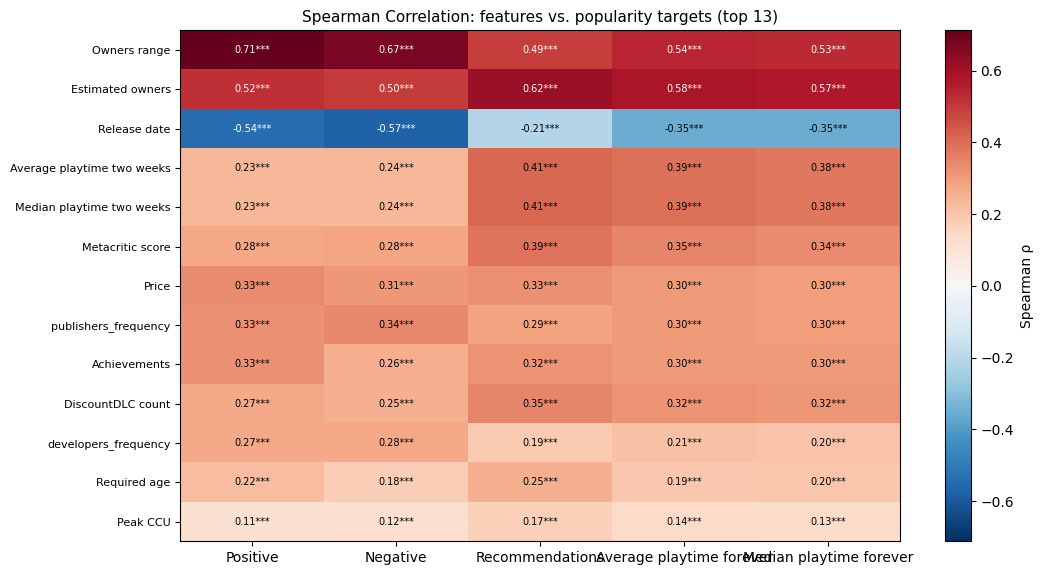

,Positive,Negative,Recommendations,Average playtime forever,Median playtime forever
Owners range,0.712,0.670,0.490,0.540,0.532
Estimated owners,0.518,0.496,0.616,0.582,0.571
Price,0.334,0.306,0.326,0.301,0.300
publishers_frequency,0.326,0.342,0.286,0.301,0.300
Achievements,0.325,0.256,0.321,0.304,0.304
Metacritic score,0.277,0.283,0.389,0.347,0.335
DiscountDLC count,0.268,0.252,0.347,0.320,0.315
developers_frequency,0.268,0.278,0.189,0.207,0.205
Median playtime two weeks,0.234,0.239,0.409,0.392,0.375
Average playtime two weeks,0.234,0.239,0.409,0.392,0.375


In [16]:
from statistic import correlate_features

TARGETS = ["Positive", "Negative", "Recommendations", "Average playtime forever", "Median playtime forever"]

# Use only continuous numeric columns (exclude binary 0/1 flags)
features = [
    c for c in num_cols
    if c not in TARGETS
    and not df_final[c].dropna().isin([0, 1]).all()
]

rho_df = correlate_features(
    df_final,
    targets=TARGETS,
    features=features,
    annot_threshold=0,
    top_n=30,
    save_dir='results/statystyka',
)
rho_df.sort_values("Positive", ascending=False)

### 7b. Mann-Whitney U Test — Binary Features vs. Targets

The Mann-Whitney U test (non-parametric equivalent of an independent-samples t-test) checks whether two groups differ significantly in their target distribution. We apply it to every binary column (0/1) to test whether having a particular category, genre, or platform flag is associated with higher popularity.

The **rank-biserial r** effect size is reported: `r = +1` means the group with flag=1 always ranks higher; `r = −1` means always lower. Values near 0 indicate no systematic difference.

[mann_whitney_binary_scan]  binary cols=111  targets=5  tests=510

                                   col                   target    n_0    n_1  median_0  median_1  effect_r            U  p_value sig
                                 Linux          Recommendations 106905  15706       0.0       0.0    0.0987  756639744.0      0.0 ***
           supported_language_japanese          Recommendations  95404  27207       0.0       0.0    0.2271 1003047424.0      0.0 ***
           supported_language_japanese Average playtime forever  95404  27207       0.0       0.0    0.1922 1048362496.0      0.0 ***
           supported_language_japanese  Median playtime forever  95404  27207       0.0       0.0    0.1910 1049900032.0      0.0 ***
             supported_language_korean                 Positive 105064  17547       4.0      16.0    0.1935  743429120.0      0.0 ***
             supported_language_korean                 Negative 105064  17547       1.0       4.0    0.1906  746063360.0      0.0

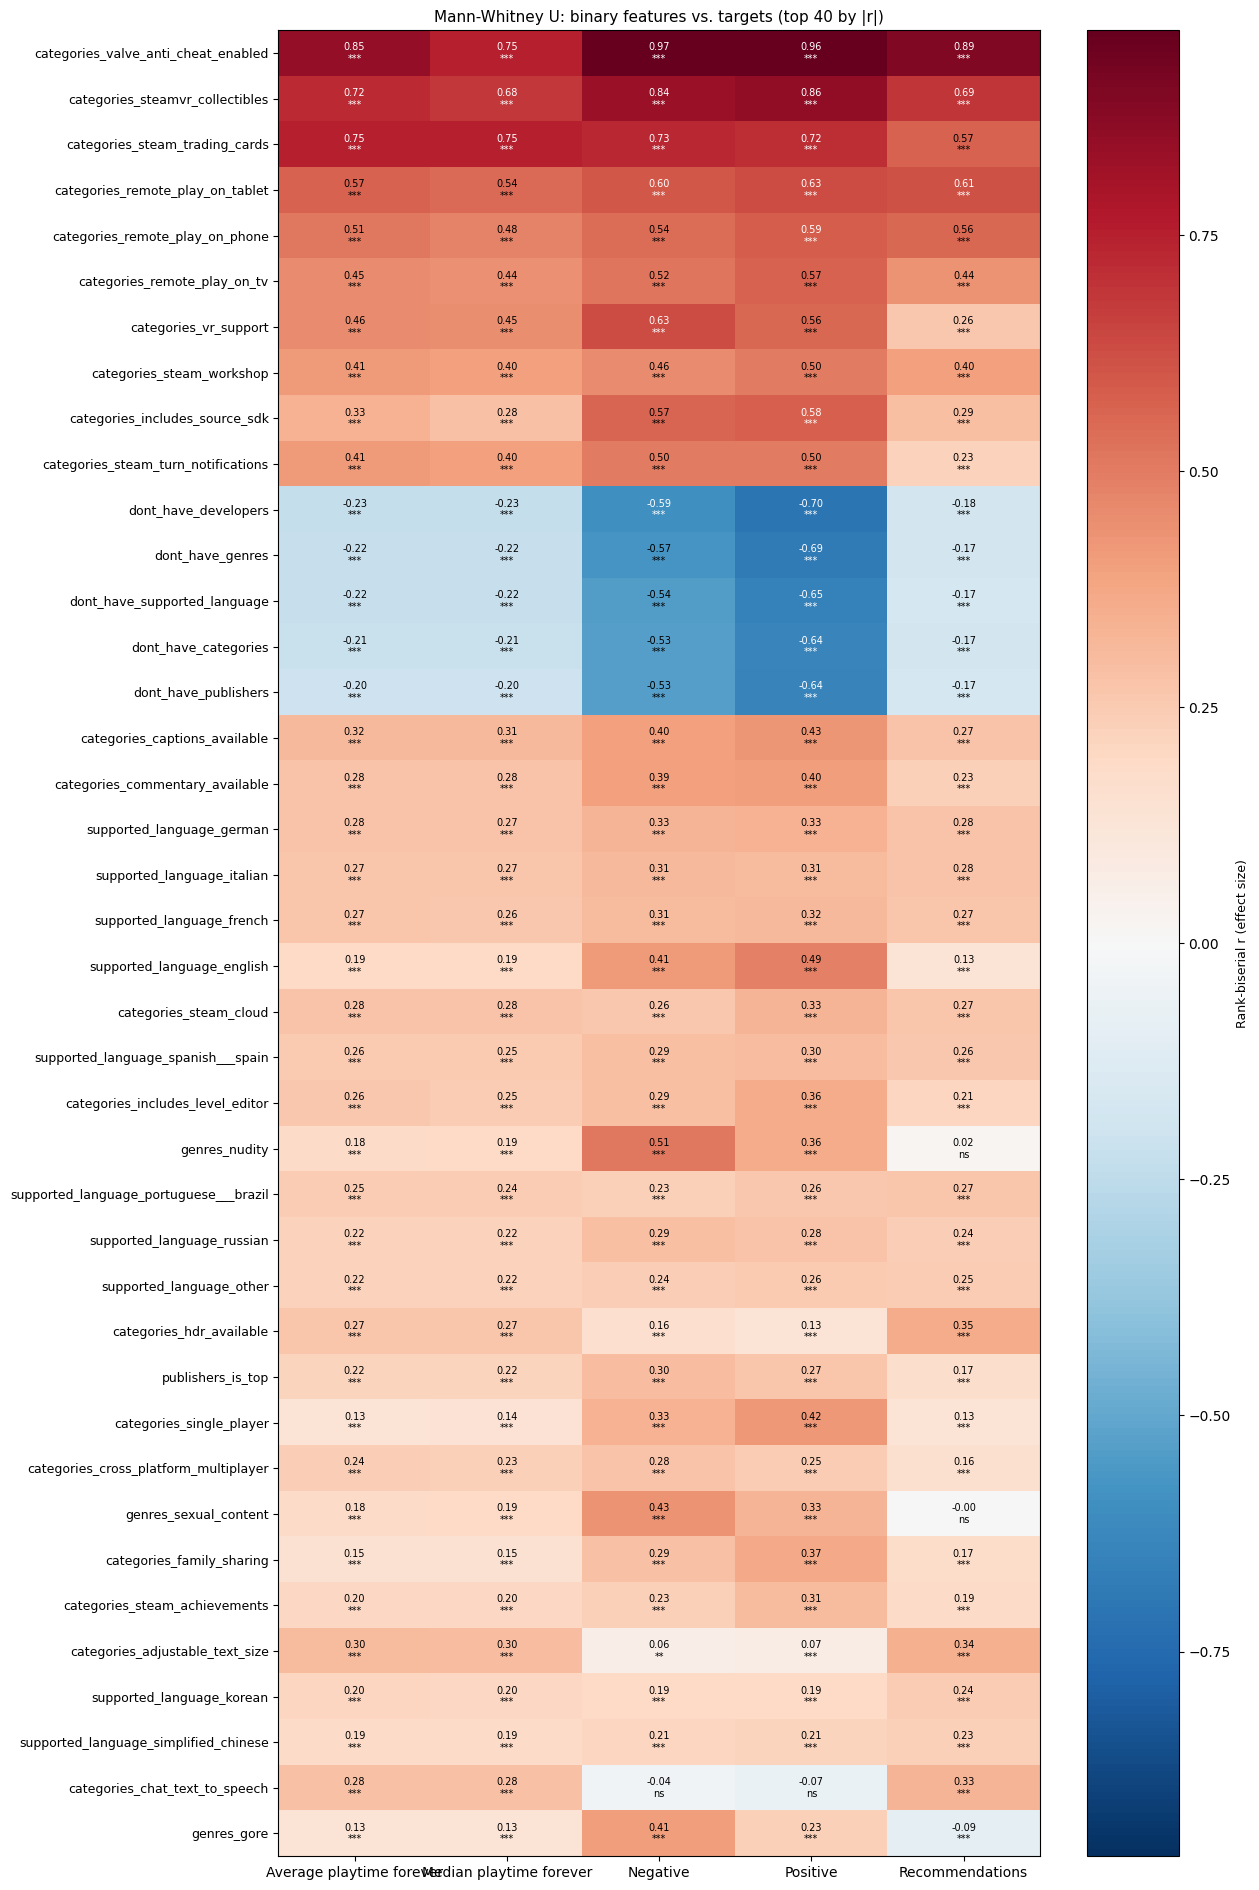

In [17]:
from statistic import mann_whitney_binary_scan, plot_mann_whitney_binary_heatmap

mw_bin = mann_whitney_binary_scan(df_final, targets=TARGETS)
plot_mann_whitney_binary_heatmap(mw_bin, top_n=40, save_dir='results/statystyka')